# Árvore de Decisão - Hábitos de Estudantes vs Performance Acadêmica
(`exam_score`).

In [15]:
# 1. Importações principais
%matplotlib inline

import os
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [16]:
# 2. Carregar o CSV
nome_arquivo = 'student_habits_performance.csv'

if not os.path.exists(nome_arquivo):
    print('Envie o arquivo student_habits_performance.csv')
    files.upload()

df = pd.read_csv(nome_arquivo)

display(df.head())
print('Linhas e colunas:', df.shape)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Linhas e colunas: (1000, 16)


In [17]:
print('Valores nulos por coluna:')
print(df.isnull().sum())

print('\nQuantidade de dados duplicados:')
print(df.duplicated().sum())

print('\nInformações do dataset:')
df.info()

print('\nEstatísticas das colunas numéricas:')
display(df.describe())

Valores nulos por coluna:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Quantidade de dados duplicados:
0

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            100

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [18]:
# 4. Tratamento básico dos dados
# Remove ID, pois não ajuda o modelo a aprender padrões
if 'student_id' in df.columns:
    df = df.drop(columns=['student_id'])

# Remove linhas duplicadas
df = df.drop_duplicates()

# Preenche valores nulos, caso existam
for coluna in df.columns:
    if df[coluna].dtype == 'object':
        df[coluna] = df[coluna].fillna(df[coluna].mode()[0])
    else:
        df[coluna] = df[coluna].fillna(df[coluna].median())

# Transforma textos em números usando One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

display(df.head())
print('Base após tratamento:', df.shape)


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,False,False,False,False,False,False,True,False,False,True
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,False,False,False,True,False,True,False,False,False,False
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,True,False,False,False,True,True,False,False,True,False
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,False,False,False,False,True,False,True,True,False,True
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,False,False,False,False,False,False,True,True,False,False


Base após tratamento: (1000, 19)


In [19]:
# 5. Separar entradas e saída
X = df.drop(columns=['exam_score'])
y = df['exam_score']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Dados de treino:', X_treino.shape)
print('Dados de teste:', X_teste.shape)


Dados de treino: (800, 18)
Dados de teste: (200, 18)


In [20]:
# 6. Treinar a Árvore de Decisão
modelo = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)


In [25]:
# 7. Métricas de avaliação para regressão
mae = mean_absolute_error(y_teste, previsoes)
mse = mean_squared_error(y_teste, previsoes)
rmse = mse ** 0.5
r2 = r2_score(y_teste, previsoes)

print('MAE:', round(mae, 2))
print('MSE:', round(mse, 2))
print('RMSE:', round(rmse, 2))
print('R²:', round(r2, 2))


MAE: 6.96
MSE: 75.64
RMSE: 8.7
R²: 0.71


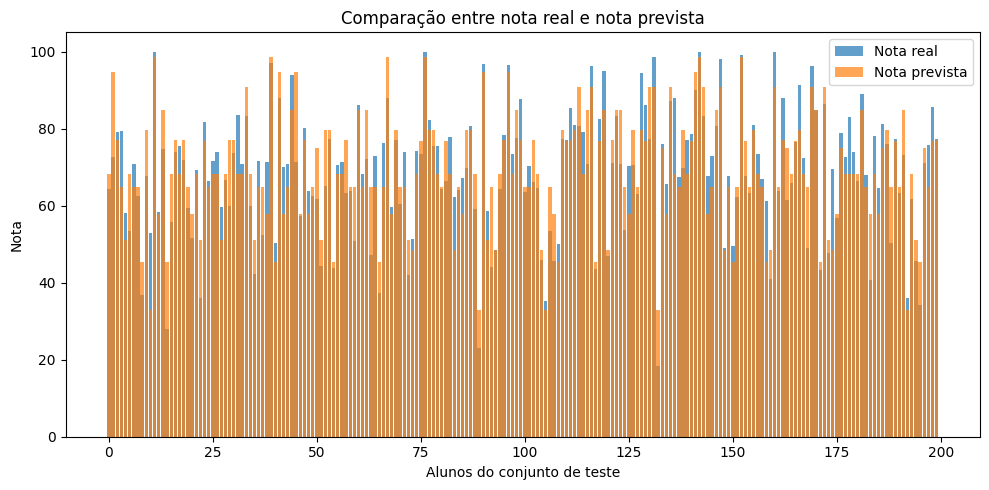

In [22]:
# 8. Gráfico: notas reais x notas previstas
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(range(len(y_teste)), y_teste.values, label='Nota real', alpha=0.7)
plt.bar(range(len(previsoes)), previsoes, label='Nota prevista', alpha=0.7)

plt.xlabel('Alunos do conjunto de teste')
plt.ylabel('Nota')
plt.title('Comparação entre nota real e nota prevista')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_barras_real_previsto.png', dpi=160)
plt.show()



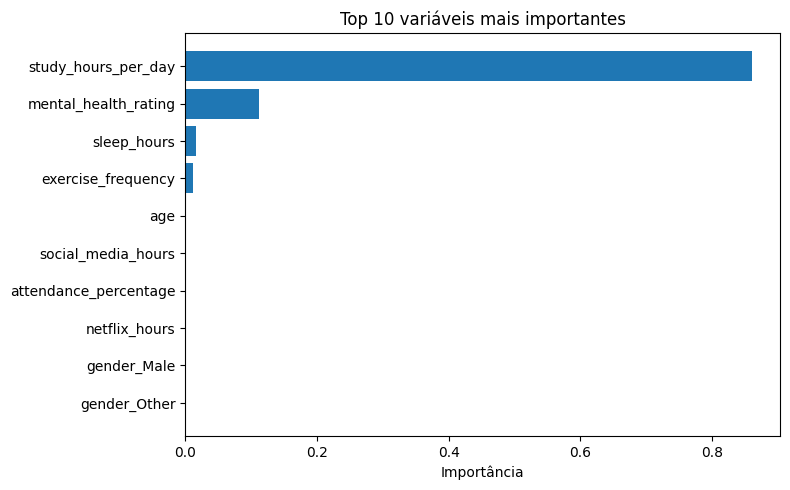

,variavel,importancia
1,study_hours_per_day,0.860065
7,mental_health_rating,0.112707
5,sleep_hours,0.015944
6,exercise_frequency,0.011284
0,age,0.000000
2,social_media_hours,0.000000
4,attendance_percentage,0.000000
3,netflix_hours,0.000000
8,gender_Male,0.000000
9,gender_Other,0.000000


In [23]:
# 9. Gráfico: importância das variáveis
importancias = pd.DataFrame({
    'variavel': X.columns,
    'importancia': modelo.feature_importances_
}).sort_values(by='importancia', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importancias['variavel'], importancias['importancia'])
plt.gca().invert_yaxis()
plt.xlabel('Importância')
plt.title('Top 10 variáveis mais importantes')
plt.tight_layout()
plt.savefig('grafico_importancia_variaveis.png', dpi=160)
plt.show()

display(importancias)


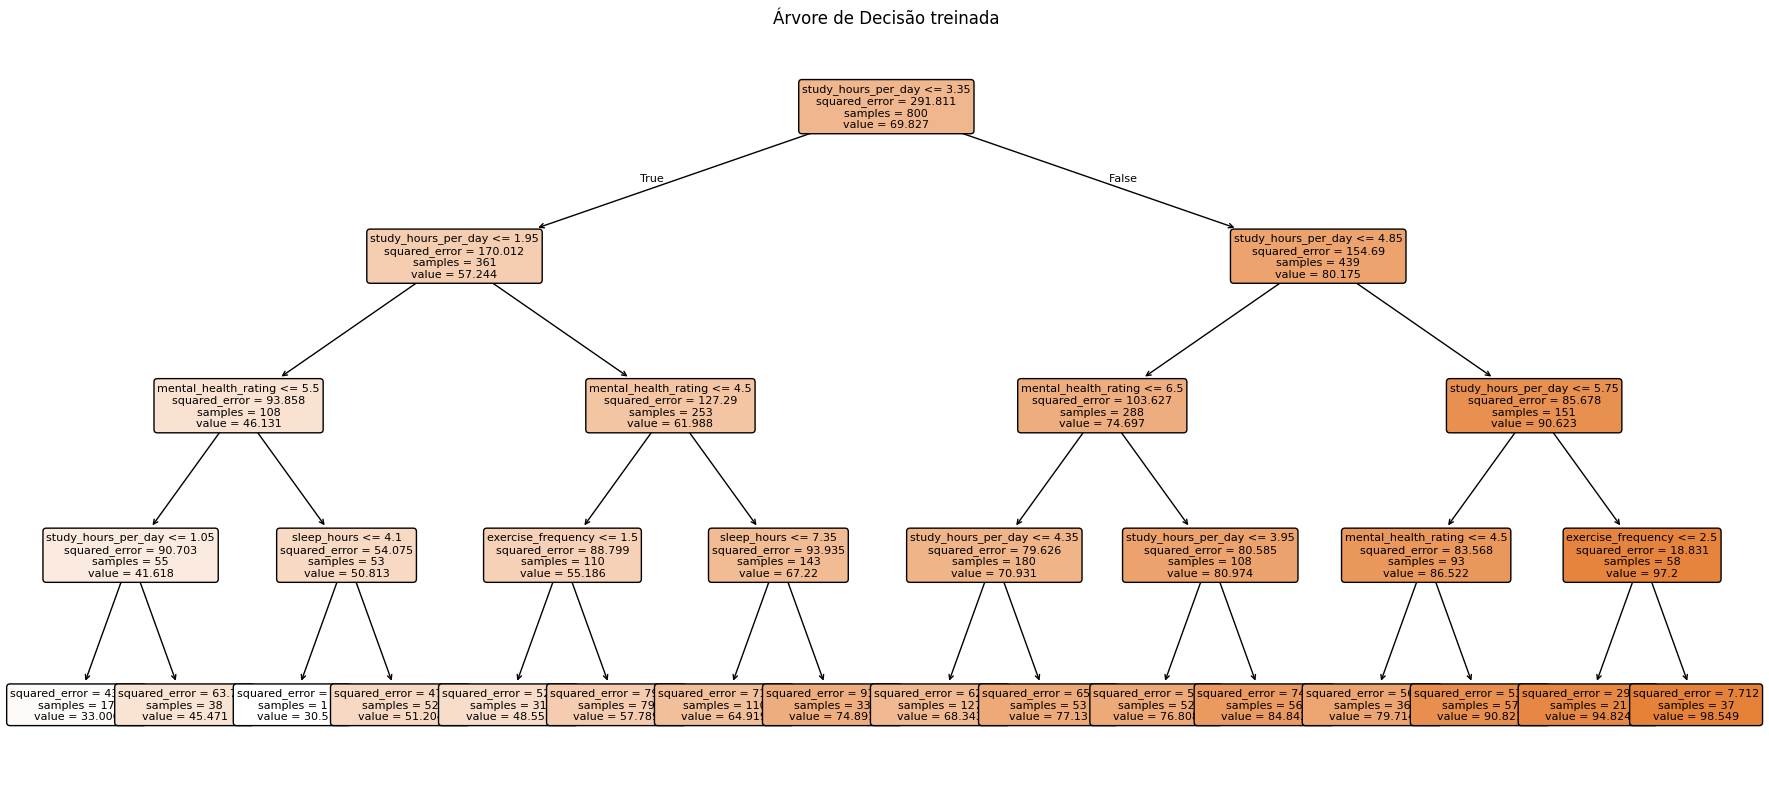

In [24]:
# 10. Visualização simplificada da árvore
plt.figure(figsize=(18, 8))
plot_tree(
    modelo,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Árvore de Decisão treinada')
plt.tight_layout()
plt.savefig('grafico_arvore_decisao.png', dpi=160)
plt.show()


## Conclusão para usar no README/PDF

Como a variável alvo `exam_score` representa uma nota de 0 a 100, o problema foi tratado como **regressão**. Por isso, as métricas usadas foram MAE, MSE, RMSE e R². O modelo utilizado foi uma **Árvore de Decisão Regressora**, capaz de separar os dados em regras simples e interpretar quais hábitos mais influenciam a nota final dos estudantes.